In [60]:
from pathlib import Path
import re
import pandas as pd

DATASET_ROOT = Path("../data_resized/")

pat = re.compile(
    r"^(?P<actor>[^_]+)_(?P<action>.+)_HD_instance(?P<instance>\d+)_(?P<frame>\d+)\.png$",
    re.I,
)

rows = []
for p in sorted(DATASET_ROOT.rglob("*.png")):
    if "__MACOSX" in p.parts or p.name.startswith("._"):
        continue  # ignore archive artefacts
    m = pat.match(p.name)
    if not m:
        continue
    rows.append(
        dict(
            path=str(p),
            gesture=p.relative_to(DATASET_ROOT).parts[
                0
            ],  # label = top-level folder
            actor=m["actor"],
            instance=int(m["instance"]),
            frame=int(m["frame"]),
            instance_uid=f'{m["actor"]}|{p.relative_to(DATASET_ROOT).parts[0]}|{m["instance"]}',
        )
    )

df = pd.DataFrame(rows)
print(f"frames    : {len(df)}")
print(f"instances : {df['instance_uid'].nunique()}")
print(f"actors    : {df['actor'].nunique()}")
print(f"classes   : {df['gesture'].nunique()}")

# integrity check: every instance should have exactly 5 frames
bad = df.groupby("instance_uid")["frame"].nunique()
assert (
    bad == 5
).all(), f"instances without exactly 5 frames: {bad[bad != 5].index.tolist()}"
print("OK: every instance has 5 frames")

frames    : 5295
instances : 1059
actors    : 11
classes   : 13
OK: every instance has 5 frames


In [61]:
print(df.head(5))

                                                path   gesture actor  \
0  ../data_resized/AllClear/S1/Instance1/S1_allCl...  AllClear    S1   
1  ../data_resized/AllClear/S1/Instance1/S1_allCl...  AllClear    S1   
2  ../data_resized/AllClear/S1/Instance1/S1_allCl...  AllClear    S1   
3  ../data_resized/AllClear/S1/Instance1/S1_allCl...  AllClear    S1   
4  ../data_resized/AllClear/S1/Instance1/S1_allCl...  AllClear    S1   

   instance  frame   instance_uid  
0         1      1  S1|AllClear|1  
1         1      2  S1|AllClear|1  
2         1      3  S1|AllClear|1  
3         1      4  S1|AllClear|1  
4         1      5  S1|AllClear|1  


Tensor -> ndim: 3, shape: torch.Size([512, 512, 3])


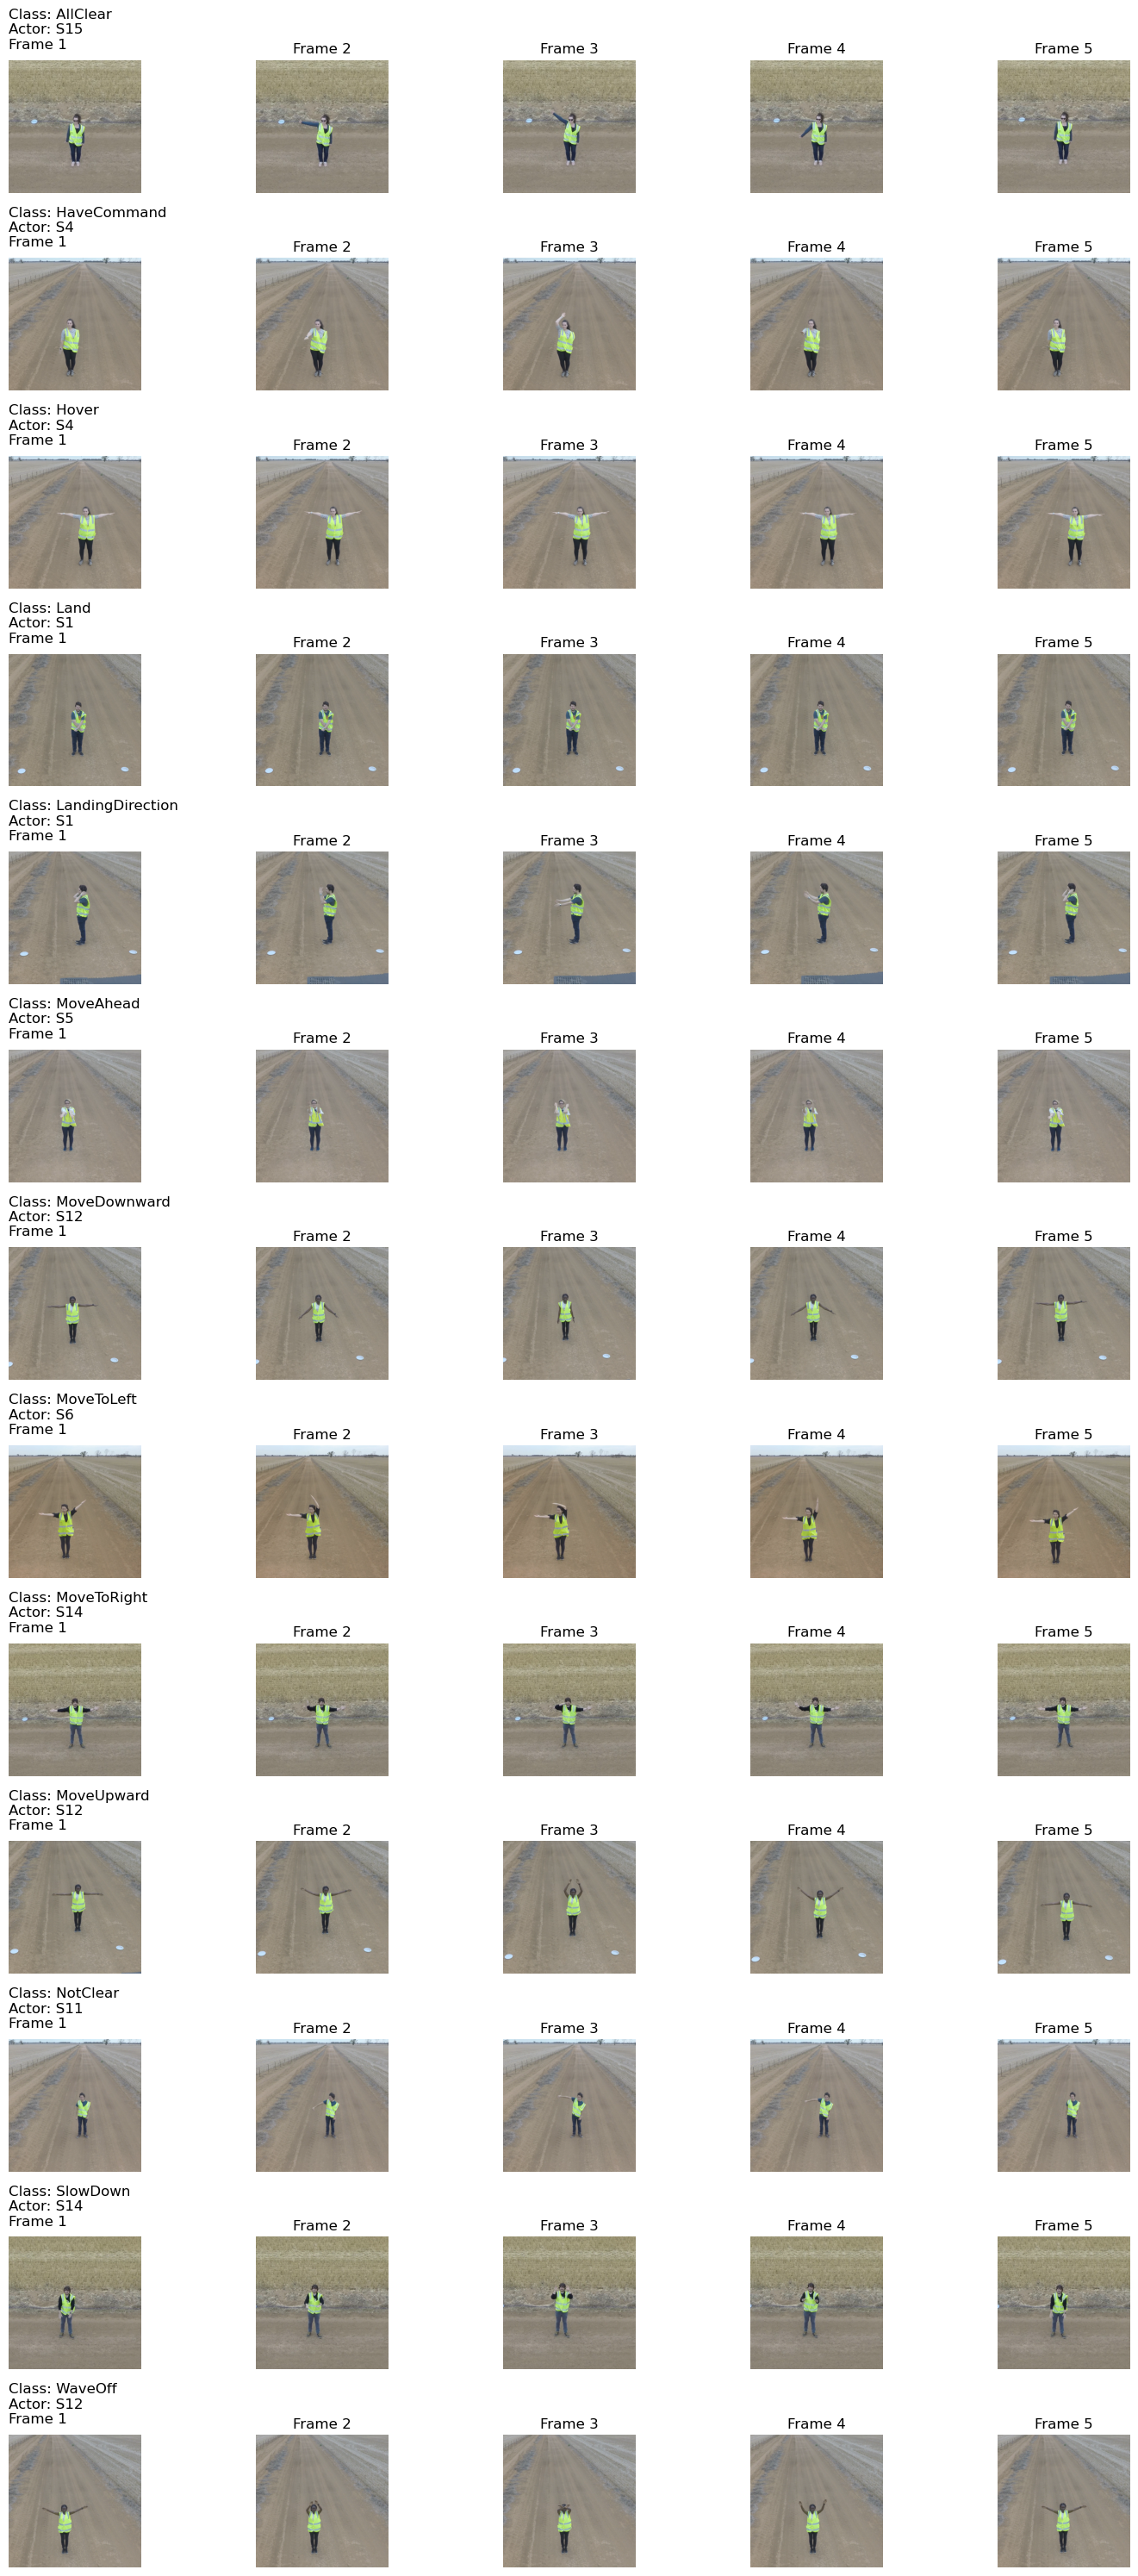

In [62]:
#randomly load a set up images as a tensor to see how the they look like
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

#get 13 unique gesture classes, sort a-z
classes = sorted(df['gesture'].unique())
#create fig A. 13 rows and 5 frames
fig, axes = plt.subplots(nrows=len(classes), ncols=5, figsize=(15, 30))

#set to false to not print each time
printed_tensor_stats = False

#iterate through
for i, gesture in enumerate(classes):
    gesture_df = df[df['gesture'] == gesture]
    #get random instance
    random_instance = np.random.choice(gesture_df['instance_uid'].unique())
    #and 5 rows
    instance_df = gesture_df[gesture_df['instance_uid'] == random_instance].sort_values('frame')
    #grab the five sequence and plot
    for j, (_, row) in enumerate(instance_df.iterrows()):
        ax = axes[i, j]

        #load into PIL
        pil_img = Image.open(row['path'])
        #into numpy array, and pytorch
        np_image = np.array(pil_img)
        tensor_image = torch.as_tensor(np_image)
        
        #display the image
        if not printed_tensor_stats:
            print(f"Tensor -> ndim: {tensor_image.ndim}, shape: {tensor_image.shape}")
            printed_tensor_stats = True
        
        ax.imshow(np_image)
        ax.axis('off')
        #add in the titles
        if j == 0:
            ax.set_title(f"Class: {gesture}\nActor: {row['actor']}\nFrame {row['frame']}", fontsize=12, loc='left', pad=10)
        else:
            ax.set_title(f"Frame {row['frame']}", fontsize=12)
#format evenly the layout
plt.tight_layout()
plt.show()


What can be noticed from the randomly selected sequence subsets of each action is that:
+ the people doing the gestures are at different distances, some are closer and others are further away -
  This is an important observation as we do not want our model to predict the gesture based on the size or aspect of the sequence
+ the backgtound in these images are different, although some share the same backdrop and we do not want that to be considered by the model
+ Some of the sequences have small circulare objects that appear to be cones perhaps for disgnating areas and we don't want those to be a factor in our model also
+ the operators performing the gestures in the samples are not always in the centre of the shot and the model should be able to cater for this  


All sequences have same dimensions.


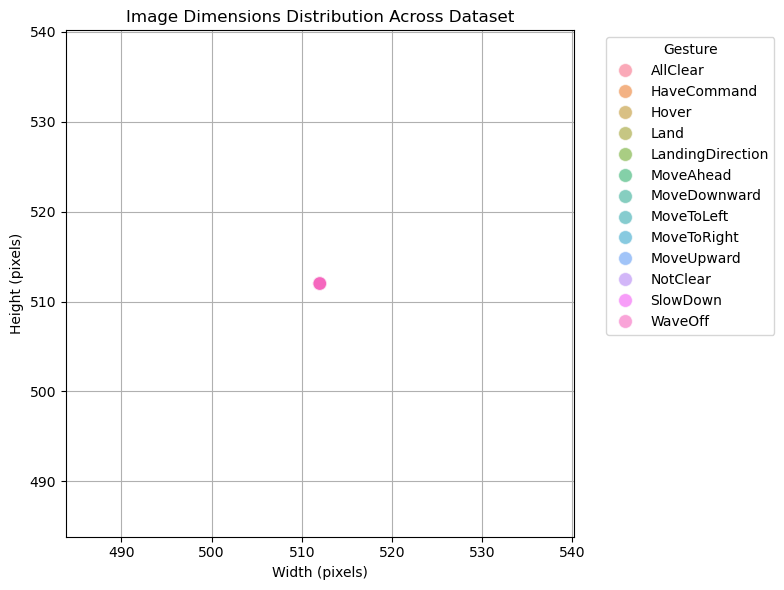

In [63]:
#check the dimensions of the images to see any variations
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

#extract the image sizes
def get_image_size(filepath):
    with Image.open(filepath) as img:
        return img.size
#traverse each dir
sizes = [get_image_size(path) for path in df['path']]
#get their widths and heights
df['width'] = [size[0] for size in sizes]
df['height'] = [size[1] for size in sizes]

#unique_sizes
unique_sizes = df[['width', 'height']].drop_duplicates()

#gather a set of possible sizes
dim_counts = df.groupby('instance_uid')[['width', 'height']].nunique()
mixed_resolution_instances = (dim_counts['width'] > 1) | (dim_counts['height'] > 1)

if mixed_resolution_instances.any():
    print(f"\nFound {mixed_resolution_instances.sum()} different image sizes in the same sequence.")
else:
    print("\nAll sequences have same dimensions.")

#chart them
plt.figure(figsize=(8, 6))
#display with a scatter plot
sns.scatterplot(
    data=df, 
    x='width', 
    y='height', 
    hue='gesture', 
    alpha=0.6, 
    s=100
)
plt.title('Image Dimensions Distribution Across Dataset')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True)
plt.legend(title='Gesture', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



+ We can see that all the sequences share the same dimensions
+ the all have:
  + width 512
  + height 512
  + count 5295

Tensor:
+ shape: torch.Size([512, 512, 3])
           

In [64]:
#set up train test split

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


#set up the data, transform to a tensor and organise training and test data
#20% is test and 80% are training
#Extract class names and create a mapping to integers
CLASS_NAMES = sorted(df['gesture'].unique().tolist())
class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASS_NAMES)}
#Split by 'instance_uid' frames from the same sequence
unique_instances = df['instance_uid'].unique()
train_instances, test_instances = train_test_split(
    unique_instances, test_size=0.2, random_state=42
)

train_df = df[df['instance_uid'].isin(train_instances)].reset_index(drop=True)
test_df = df[df['instance_uid'].isin(test_instances)].reset_index(drop=True)

In [65]:
#pytorch gestures dataset
class GestureSequenceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        #group by instance so each index grabs 1 sequence of images
        self.instances = list(dataframe.groupby('instance_uid'))
        self.transform = transform
        
    def __len__(self):
        #Returns the total number of frames
        return len(self.instances)
    
    def __getitem__(self, idx):
        #get the row data
        uid, instance_df = self.instances[idx]

        instance_df = instance_df.sort_values('frame')

        frames = []
        for _, row in instance_df.iterrows():
            img = Image.open(row['path']).convert("RGB")
            if self.transform:
                img = self.transform(img)
            frames.append(img)
            
        #stack the five frames into a single tensor shape (5, C, H, W)
        sequence_tensor = torch.stack(frames)

        #frames in the sequence have the same label
        label_str = instance_df.iloc[0]['gesture']
        label = class_to_idx[label_str]

        return sequence_tensor, label

In [66]:
#convert to a tensor
base_transform = transforms.Compose([
    #resize images to be smaller -> this is to limit the vram
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])
#instanstiate classes
full_train_dataset = GestureSequenceDataset(
    dataframe=train_df, 
    transform=base_transform
)

test_dataset = GestureSequenceDataset(
    dataframe=test_df, 
    transform=base_transform
)
print(f"Train Dataset: {len(full_train_dataset)} sequences")
print(f"Test Dataset : {len(test_dataset)} sequences")
print(f"Class Names  : {CLASS_NAMES}")


Train Dataset: 847 sequences
Test Dataset : 212 sequences
Class Names  : ['AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection', 'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight', 'MoveUpward', 'NotClear', 'SlowDown', 'WaveOff']


In [67]:
from torch.utils.data import Subset

#Shuffle 847 sequences and keep the indcies
torch.manual_seed(42)
seq_indices = torch.randperm(len(full_train_dataset)).tolist()

#split the train_df into train and valid 80/20
train_indices = seq_indices[:677]
val_indices = seq_indices[677:]

#create pytorch subsets
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

#print subsets lengths
print("-" * 30)
print(f'Subset Training samples:   {len(train_dataset)}')
print(f'Subset Validation samples: {len(val_dataset)}')
print(f'Test samples:       {len(test_dataset)}')

------------------------------
Subset Training samples:   677
Subset Validation samples: 170
Test samples:       212


In [68]:
#set up the dataloaders train, val and test
train_loader = DataLoader(
    train_dataset,
    batch_size=25, #25 x 5
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=50, #50 x 5
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=50, #50 x 5
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [69]:
# Get one batch to inspect
sequences, labels = next(iter(train_loader))

print(f'Batch shape: {sequences.shape}')
print(f'  (batch_size={sequences.shape[0]}, frames={sequences.shape[1]}, channels={sequences.shape[2]}, height={sequences.shape[3]}, width={sequences.shape[4]})')
print(f'Labels shape: {labels.shape}')
print(f'Pixel value range: [{sequences.min():.3f}, {sequences.max():.3f}]')

Batch shape: torch.Size([25, 5, 3, 128, 128])
  (batch_size=25, frames=5, channels=3, height=128, width=128)
Labels shape: torch.Size([25])
Pixel value range: [0.035, 1.000]


each sequence is made up of 5 frames, of 3 channels for the Red, Blue and Green, that have a pixel height of 512 and width of 512

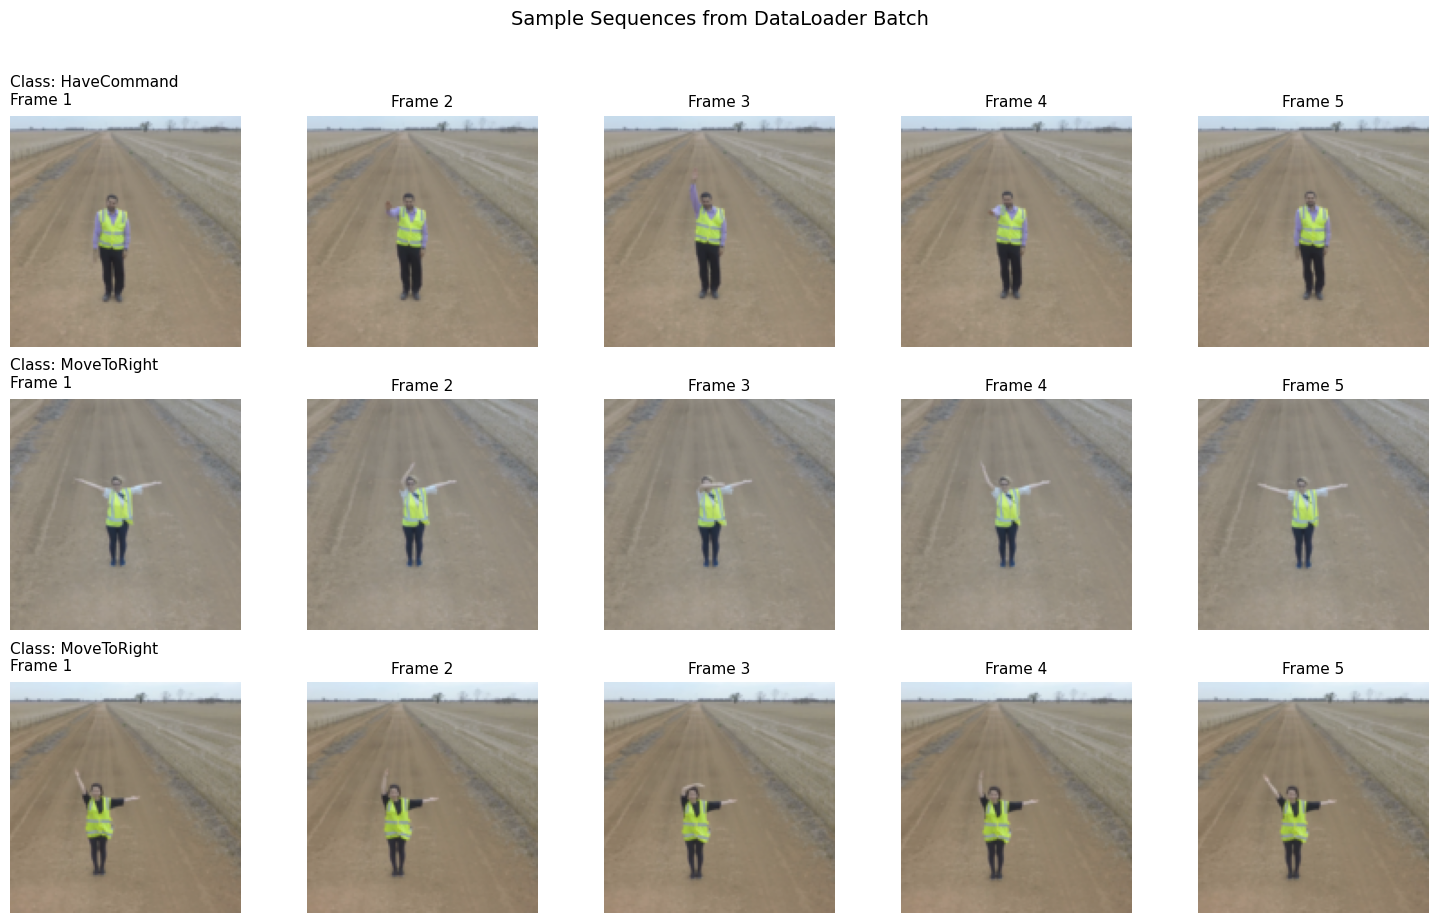

In [70]:
#visiualize 3 samples of 5 image sequences
#get a batch
sequences, labels = next(iter(train_loader))

#shows 3 sample sequences 
num_sequences_to_show = 3
fig, axes = plt.subplots(num_sequences_to_show, 5, figsize=(15, 3 * num_sequences_to_show))

for i in range(num_sequences_to_show):
    #5 frames per sequence
    for j in range(5): 
        ax = axes[i, j]
        
        # sequences[i] is the sequence, sequences[i, j] is the specific frame
        # permute from (C, H, W) to (H, W, C) for matplotlib
        img = sequences[i, j].permute(1, 2, 0).numpy()
        
        ax.imshow(img)
        ax.axis('off')
        
        # Add the class name to the first frame of each row
        if j == 0:
            ax.set_title(f"Class: {CLASS_NAMES[labels[i].item()]}\nFrame {j+1}", fontsize=11, loc='left', pad=8)
        else:
            ax.set_title(f"Frame {j+1}", fontsize=11)

plt.suptitle('Sample Sequences from DataLoader Batch', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

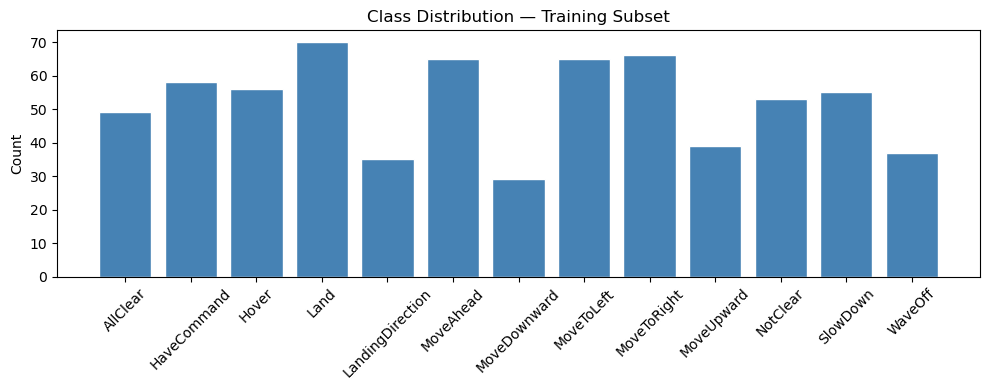

In [71]:
#check the class distribution
# Extract labels
all_labels = []
for i in train_indices:
    # full_train_dataset.instances[i] returns (instance_uid, instance_df)
    uid, instance_df = full_train_dataset.instances[i]
    
    # get the string label from the first row of this sequence
    label_str = instance_df.iloc[0]['gesture']
    all_labels.append(label_str)

#Count the occurrences
unique, counts = np.unique(all_labels, return_counts=True)

#Plot the distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution — Training Subset')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The classes of the training set are not well balanced:
+ landing direction, Move Downward, Move Upward, Waveoff are short
+ Land, Moveahead, MoeToleft and MoveToRight outnumber the rest

##########
First run:
CNN_128_RGB
Method A. Input batch of 5 individual RGB images, Each image of the sequence. There 
##########

In [72]:
#Training Utilities
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct, total = 0, 0

    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item() * y.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model'):
    """Run a training experiment and return history dict."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    return history

In [78]:
#plot experiments
def plot_experiments(results, show_train=True, show_val=True):
    """Plot training and validation loss + accuracy for multiple experiments."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax = axes[0]
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            ax.plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=4)
        if show_val:
            ax.plot(epochs, hist['val_loss'], label=f'{name} (Val)', marker='x', markersize=4, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # Accuracy
    ax = axes[1]
    for name, hist in results.items():
        epochs = range(1, len(hist['train_acc']) + 1)
        if show_train:
            ax.plot(epochs, hist['train_acc'], label=f'{name} (Train)', marker='o', markersize=4)
        if show_val:
            ax.plot(epochs, hist['val_acc'], label=f'{name} (Val)', marker='x', markersize=4, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [79]:
import torch
import torch.nn as nn
import torch.optim as optim

#CNN_128_RGB
class CNN_128_RGB(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Input: (3, 32, 32)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # -> (32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # -> (64, 8, 8)
        )
        #use the average over the batch
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        #5D tensor from the Dataloader,
        # each sequence frame is a time step -> T (there are 5)
        # x -> shape: (batch, 5, 3, H, W)
        B, T, C, H, W = x.shape
        
        #fold into batch for the con2d, 
        # updates the shape: (batch x T, C, H, W)
        x = x.view(B * T, C, H, W)

        #feature extract        
        x = self.conv_block(x)
        x = self.adaptive_pool(x)

        #classify each frame
        self.classifier(x)

        #unfold predictions back into the sequence
        #shape is (batch, number of classes)
        x = x.view(B, T, -1)

        #take the average of the 5 frame predictions to make a total sequence prediction
        end_prediction = x.mean(dim=1)
        
        return end_prediction

num_classes = len(CLASS_NAMES)
cnn = CNN_128_RGB(num_classes=num_classes)
n_params = sum(p.numel() for p in cnn.parameters())
print(f'CNN_128_RGB parameters: {n_params:,}')
print(cnn)

CNN_128_RGB parameters: 545,485
CNN_128_RGB(
  (conv_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=13, bias=True)
  )
)


Training on device: cuda
  [CNN_128_RGB] Epoch 1/10 — Train Loss: 8.3247, Train Acc: 0.0222 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_128_RGB] Epoch 2/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_128_RGB] Epoch 4/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_128_RGB] Epoch 6/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_128_RGB] Epoch 8/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_128_RGB] Epoch 10/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882


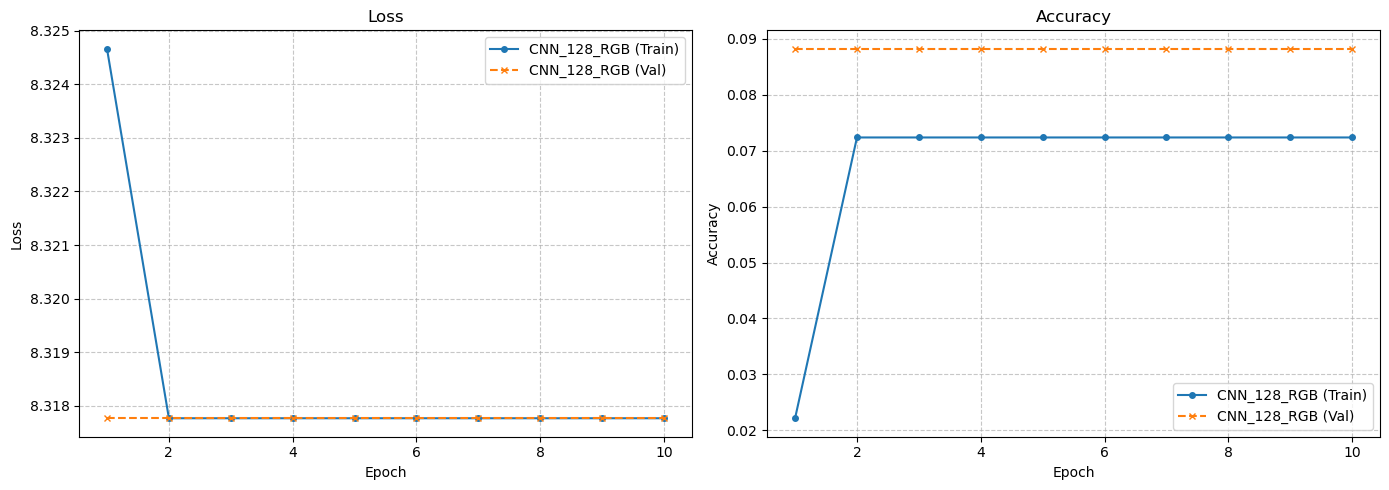

In [80]:
#plot the results
results = {}

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Training on device: {device}")

torch.manual_seed(0)
cnn = CNN_128_RGB(num_classes).to(device)
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results['CNN_128_RGB'] = run_experiment(cnn, optimizer, criterion, train_loader, val_loader,
                                       epochs=10, name='CNN_128_RGB')

plot_experiments(results)

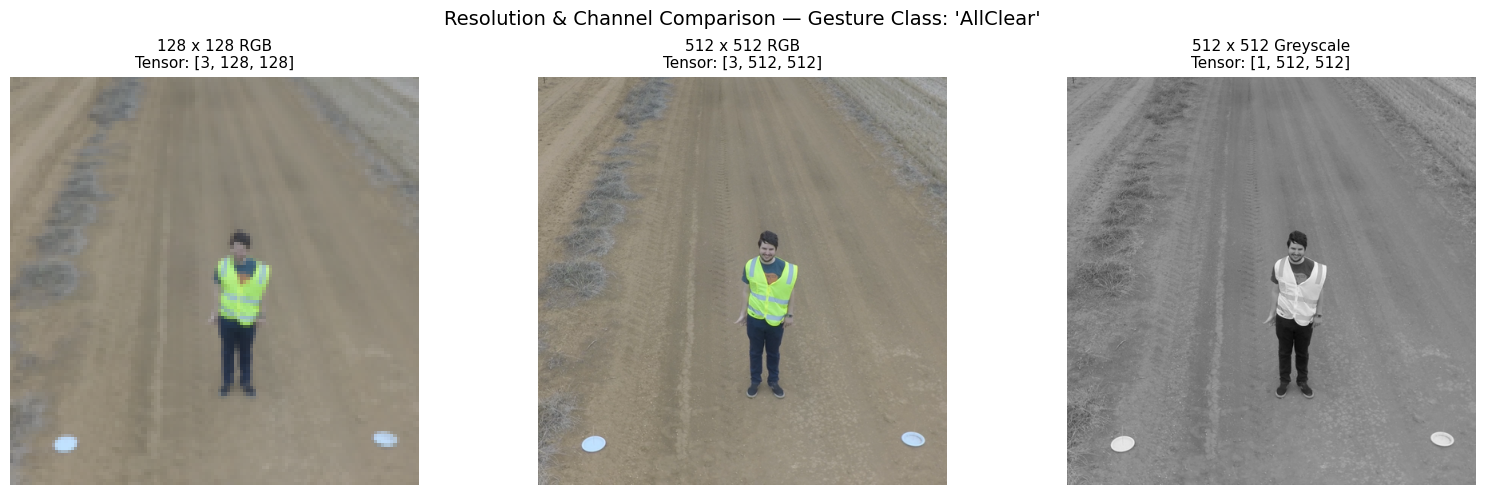

In [43]:
#show the side by side image of 512 x 512 RGB vs 512 x 512 Greyscale vs 128 x 128 RGB
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

#3 transform variations
#128 RGB
transform_128_rgb = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
#512 RGB
transform_512_rgb = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])
#512 Grey
transform_512_grey = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

#get sample image path directly from train.df
sample_row = train_df.iloc[0]
pil_img = Image.open(sample_row['path']).convert("RGB")
sample_label = sample_row['gesture']

#make transformations and convert
tensor_128_rgb = transform_128_rgb(pil_img)
tensor_512_rgb = transform_512_rgb(pil_img)
tensor_512_grey = transform_512_grey(pil_img)

img_128_rgb = tensor_128_rgb.permute(1, 2, 0).numpy()
img_512_rgb = tensor_512_rgb.permute(1, 2, 0).numpy()
img_512_grey = tensor_512_grey.squeeze().numpy()  # Drop channel dim for 2D plot

#plot side by side for visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 128x128 RGB
axes[0].imshow(img_128_rgb)
axes[0].set_title(f"128 x 128 RGB\nTensor: {list(tensor_128_rgb.shape)}", fontsize=11)
axes[0].axis('off')

# 512x512 RGB
axes[1].imshow(img_512_rgb)
axes[1].set_title(f"512 x 512 RGB\nTensor: {list(tensor_512_rgb.shape)}", fontsize=11)
axes[1].axis('off')

# 512x512 Greyscale
axes[2].imshow(img_512_grey, cmap='grey')
axes[2].set_title(f"512 x 512 Greyscale\nTensor: {list(tensor_512_grey.shape)}", fontsize=11)
axes[2].axis('off')

plt.suptitle(f"Resolution & Channel Comparison — Gesture Class: '{sample_label}'", fontsize=14)
plt.tight_layout()
plt.show()

  [CNN_512_Grey] Epoch 1/10 — Train Loss: 8.3190, Train Acc: 0.0458 | Val Loss: 8.3178, Val Acc: 0.0647
  [CNN_512_Grey] Epoch 2/10 — Train Loss: 8.3178, Train Acc: 0.0576 | Val Loss: 8.3178, Val Acc: 0.0765
  [CNN_512_Grey] Epoch 4/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_512_Grey] Epoch 6/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_512_Grey] Epoch 8/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882
  [CNN_512_Grey] Epoch 10/10 — Train Loss: 8.3178, Train Acc: 0.0724 | Val Loss: 8.3178, Val Acc: 0.0882


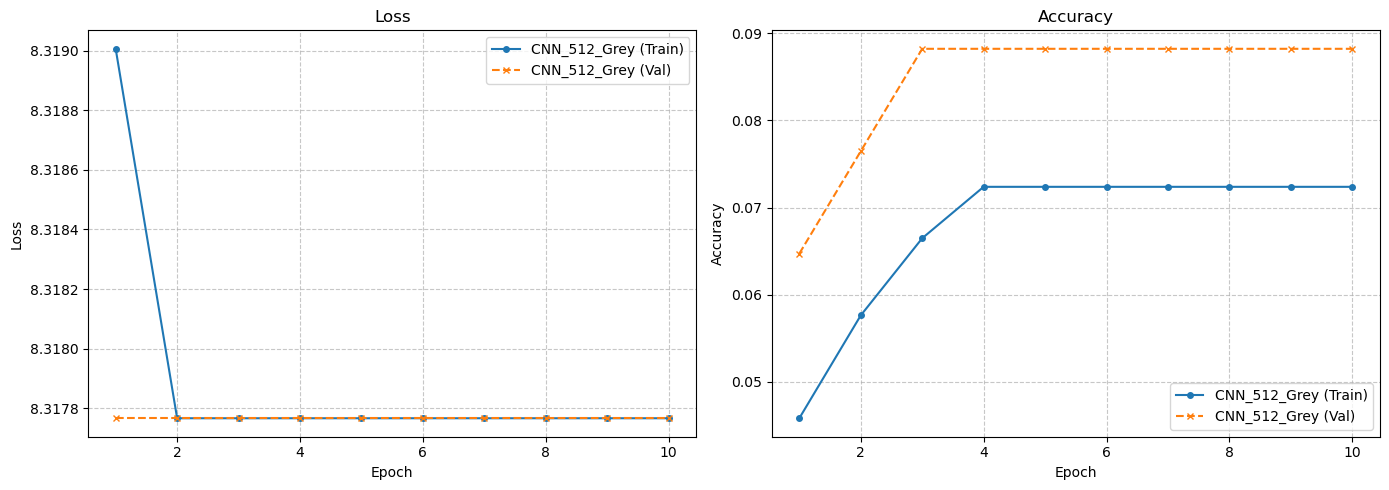

In [81]:
#CNN_512_Grey
base_transform_512_grey = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),  # Convert to 1 channel
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])   # 1-channel normalization
])

full_train_dataset = GestureSequenceDataset(train_df, transform=base_transform_512_grey)
test_dataset = GestureSequenceDataset(test_df, transform=base_transform_512_grey)

torch.manual_seed(42)
seq_indices = torch.randperm(len(full_train_dataset)).tolist()
train_indices = seq_indices[:677]
val_indices = seq_indices[677:]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,   # 4 sequences = 20 frames per batch
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,   # 8 sequences = 40 frames per batch
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


class CNN_512_Grey(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Input: (1, 512, 512)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # -> (32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # -> (64, 8, 8)
        )
        #use the average over the batch
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        #MLP classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        #5D tensor from the Dataloader,
        # each sequence frame is a time step -> T (there are 5)
        # x -> shape: (batch, 5, 3, H, W)
        B, T, C, H, W = x.shape
        
        #fold into batch for the con2d, 
        # updates the shape: (batch x T, C, H, W)
        x = x.view(B * T, C, H, W)

        #feature extract        
        x = self.conv_block(x)
        x = self.adaptive_pool(x)

        #classify each frame
        self.classifier(x)

        #unfold predictions back into the sequence
        #shape is (batch, number of classes)
        x = x.view(B, T, -1)

        #take the average of the 5 frame predictions to make a total sequence prediction
        end_prediction = x.mean(dim=1)
        
        return end_prediction

results = {}

num_classes = len(CLASS_NAMES)
cnn_grey = CNN_512_Grey(num_classes).to(device)
optimizer = optim.Adam(cnn_grey.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results['CNN_512_Grey'] = run_experiment(
    cnn_grey, 
    optimizer, 
    criterion, 
    train_loader, 
    val_loader,
    epochs=10, 
    name='CNN_512_Grey'
)

plot_experiments(results)

###############################

#CNN_512_Grey
512 x 512 in grey scale

base_transform_512_grey
vs
base_transform_512_grey_norm

###############################

In [84]:
import torch
import torch.nn as nn
import torch.optim as optim

#########################

#CNN_512_Grey
base_transform_512_grey = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),  # Convert to 1 channel
    transforms.ToTensor()
])

full_train_ds_grey = GestureSequenceDataset(train_df, transform=base_transform_512_grey)
test_ds_grey = GestureSequenceDataset(test_df, transform=base_transform_512_grey)

torch.manual_seed(42)
seq_indices = torch.randperm(len(full_train_ds_grey)).tolist()
train_indices = seq_indices[:677]
val_indices = seq_indices[677:]

train_ds_grey = Subset(full_train_ds_grey, train_indices)
val_ds_grey = Subset(full_train_ds_grey, val_indices)

train_loader_grey = DataLoader(
    train_ds_grey,
    batch_size=4,   # 4 sequences = 20 frames per batch
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_grey = DataLoader(
    val_ds_grey,
    batch_size=8,   # 8 sequences = 40 frames per batch
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#########################

#CNN_512_Grey_with_normalization -> scales pixel values from a range of 0 to 1 down to a range of -1 to 1.
base_transform_512_grey_norm = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),  # Convert to 1 channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])   # 1-channel normalization
])
full_train_ds_norm = GestureSequenceDataset(train_df, transform=base_transform_512_grey_norm)
test_ds_norm = GestureSequenceDataset(test_df, transform=base_transform_512_grey_norm)


train_ds_norm = Subset(full_train_ds_norm, train_indices)
val_ds_norm = Subset(full_train_ds_norm, val_indices)

train_loader_norm = DataLoader(
    train_ds_norm,
    batch_size=4,   # 4 sequences = 20 frames per batch
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_norm = DataLoader(
    val_ds_norm,
    batch_size=8,   # 8 sequences = 40 frames per batch
    shuffle=False,
    num_workers=2,
    pin_memory=True
)




In [85]:
class CNN_512_Grey_EarlyFusion(nn.Module):
    def __init__(self, num_classes, num_frames=5):
        super().__init__()
        
        #in_channels = 5 (5 grayscale frames * 1 channel per frame)
        self.conv_block = nn.Sequential(
            # Input shape: (Batch, 5, 512, 512)
            nn.Conv2d(in_channels=num_frames, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x shape from DataLoader: (Batch, 5, 1, 512, 512)
        B, T, C, H, W = x.shape
        
        # Merge Time (T) into Channels (C): shape becomes (Batch, 5, 512, 512)
        x = x.view(B, T * C, H, W)

        # Process sequence all at once in a single forward pass
        x = self.conv_block(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        # return (Batch, num_classes)
        return x 



In [ ]:
results = {}

num_classes = len(CLASS_NAMES)
criterion = nn.CrossEntropyLoss()

cnn_grey = CNN_512_Grey_EarlyFusion(num_classes).to(device)
optimizer_grey = optim.Adam(cnn_grey.parameters(), lr=1e-3)
results['CNN_Grey'] = run_experiment(
    cnn_grey, 
    optimizer_grey, 
    criterion, 
    train_loader_grey, 
    val_loader_grey,
    epochs=10, 
    name='CNN_Grey'
)

cnn_grey_norm = CNN_512_Grey_EarlyFusion(num_classes).to(device)
optimizer_grey_norm = optim.Adam(cnn_grey.parameters(), lr=1e-3)
results['CNN_Grey_norm'] = run_experiment(
    cnn_grey_norm, 
    optimizer_grey_norm, 
    criterion, 
    train_loader_norm, 
    val_loader_norm,
    epochs=10, 
    name='CNN_Grey_norm'
)



plot_experiments(results)

  [CNN_Grey] Epoch 1/10 — Train Loss: 2.5626, Train Acc: 0.0739 | Val Loss: 2.5517, Val Acc: 0.1588
  [CNN_Grey] Epoch 2/10 — Train Loss: 2.5292, Train Acc: 0.1123 | Val Loss: 2.4741, Val Acc: 0.1765
